In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

In [78]:
## load dataset
df = pd.read_csv("creditcard.csv.zip",compression='zip')

print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [79]:
## Dataset Info
print("Dataset Shape:", df.shape)

print(df['Class'].value_counts())

Dataset Shape: (284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [80]:
## Check Missing Values
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


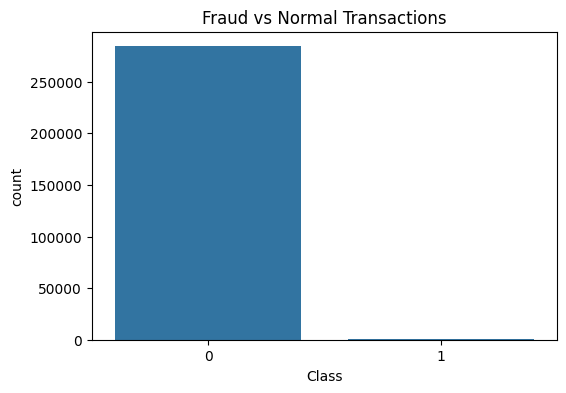

In [81]:
## Fraud vs Normal Visualization
plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title("Fraud vs Normal Transactions")

plt.show()

In [82]:
## Feature Scaling
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])

In [83]:
## Drop Time Column
df = df.drop('Time', axis=1)

In [84]:
## Separate Fraud and Normal Transactions
fraud = df[df['Class'] == 1]

normal = df[df['Class'] == 0]

In [85]:
## Undersampling
normal_sample = resample(
    normal,
    replace=False,
    n_samples=len(fraud) * 2,
    random_state=42
)

In [86]:
## Creating Undersampled Dataset
undersampled_data = pd.concat([normal_sample, fraud])

undersampled_data = undersampled_data.sample(frac=1, random_state=42)

print(undersampled_data['Class'].value_counts())

Class
0    984
1    492
Name: count, dtype: int64


In [87]:
## Split Features and Target
X = undersampled_data.drop('Class', axis=1)

y = undersampled_data['Class']

In [88]:
## Applying SMOTE
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print(pd.Series(y_resampled).value_counts())

Class
1    984
0    984
Name: count, dtype: int64


In [89]:
## Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

In [90]:
## Isolation Forest Model
model = IsolationForest(
    n_estimators=100,
    contamination=0.5,
    random_state=42
)

model.fit(X_train)

IsolationForest(contamination=0.5, random_state=42)

In [91]:
## Making Predictions
y_pred = model.predict(X_test)

In [92]:
## Converting Predictions
y_pred = np.where(y_pred == -1, 1, 0)

In [93]:
## Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7385786802030457


In [94]:
## Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.70      0.73       194
           1       0.73      0.78      0.75       200

    accuracy                           0.74       394
   macro avg       0.74      0.74      0.74       394
weighted avg       0.74      0.74      0.74       394



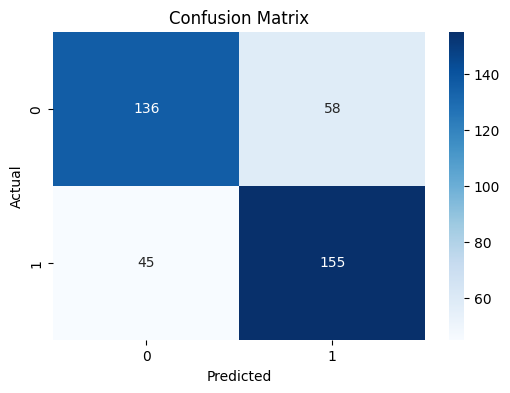

In [95]:
## Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [96]:
## Fraud Prediction System
sample_transaction = X_test.iloc[0].values.reshape(1, -1)

prediction = model.predict(sample_transaction)

if prediction[0] == -1:
    print("⚠ Fraudulent Transaction Detected")

else:
    print("✅ Legitimate Transaction")

✅ Legitimate Transaction


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


In [97]:
## PROJECT COMPLETED SUCCESSFULLY...